# 06 Bumjun MLP Model Ceiling

범준 실험 2단계. 목표: 딥러닝 계열 MLP가 단순 선형/트리 baseline을 확실히 넘어서는지 그래프로 비교한다.

In [1]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'README.md').exists() and (path / 'src').exists()
)
os.chdir(ROOT)
RIOT_1 = ROOT / 'data_1' / 'processed' / 'riot'
RIOT_2 = ROOT / 'data_2' / 'processed' / 'riot'
RIOT_3 = ROOT / 'data_3' / 'processed' / 'riot'

ID_COLS = {'match_id', 'team_id', 'feature_version', 'queue_id', 'game_version', 'collected_at', 'minute'}
LABEL_COLS = {'team_surrendered', 'win', 'final_loss'}
METRIC_COLS = ['f1', 'precision', 'recall', 'pr_auc', 'roc_auc']

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'blue': '#4e79a7',
    'orange': '#f28e2b',
    'red': '#e15759',
    'teal': '#76b7b2',
    'green': '#59a14f',
    'purple': '#b07aa1',
    'gray': '#9c9c9c',
}

def require_path(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path.relative_to(ROOT)}')
    return path

def load_data1_team_features() -> pd.DataFrame:
    return pd.read_csv(require_path(RIOT_1 / 'riot-scale-2600_team_features.csv'))

def _final_loss_map(base: Path) -> pd.DataFrame:
    positions = pd.read_csv(require_path(base / 'riot-16.9-5050_team_champion_positions.csv'))
    wins = positions.groupby(['match_id', 'team_id'], as_index=False)['win'].first()
    wins['final_loss'] = (~wins['win'].astype(bool)).astype(int)
    return wins

def load_team_features(base: Path = RIOT_3) -> pd.DataFrame:
    df = pd.read_csv(require_path(base / 'riot-16.9-5050_team_features.csv'))
    return df.merge(_final_loss_map(base), on=['match_id', 'team_id'], how='left')

def load_timeseries_features(base: Path = RIOT_3, minute: int = 15) -> pd.DataFrame:
    ts = pd.read_csv(require_path(base / 'riot-16.9-5050_team_timeseries_features.csv'))
    labels = ts[['match_id', 'team_id', 'team_surrendered']].drop_duplicates()
    labels = labels.merge(_final_loss_map(base), on=['match_id', 'team_id'], how='left')
    numeric_cols = [
        c for c in ts.columns
        if c not in ID_COLS | LABEL_COLS and pd.api.types.is_numeric_dtype(ts[c])
    ]
    current = ts[ts['minute'].eq(minute)][['match_id', 'team_id'] + numeric_cols].copy()
    current = current.rename(columns={c: f'{c}_m{minute}' for c in numeric_cols})
    early_minute = 7
    early = ts[ts['minute'].eq(early_minute)][['match_id', 'team_id'] + numeric_cols].copy()
    early = early.rename(columns={c: f'{c}_m{early_minute}' for c in numeric_cols})
    df = current.merge(early, on=['match_id', 'team_id'], how='left')
    for c in numeric_cols:
        df[f'{c}_delta_{early_minute}_{minute}'] = df[f'{c}_m{minute}'] - df[f'{c}_m{early_minute}']
    return df.merge(labels, on=['match_id', 'team_id'], how='left')

def add_counter_features(df: pd.DataFrame, base: Path = RIOT_3) -> pd.DataFrame:
    counters = pd.read_csv(require_path(base / 'external_champion_counters.csv'))
    positions = pd.read_csv(require_path(base / 'riot-16.9-5050_team_champion_positions.csv'))
    counters['target_champion_name'] = counters['target_champion_name'].astype(str).str.lower()
    counters['counter_champion_name'] = counters['counter_champion_name'].astype(str).str.lower()
    counters['win_rate'] = pd.to_numeric(counters['win_rate'], errors='coerce')
    counter_strength = (
        counters.groupby('counter_champion_name')['win_rate'].mean()
        .rename('counter_avg_win_rate').reset_index()
        .rename(columns={'counter_champion_name': 'champion_name'})
    )
    counter_allowed = (
        counters.groupby('target_champion_name')['win_rate'].mean()
        .rename('target_counter_win_rate_allowed').reset_index()
        .rename(columns={'target_champion_name': 'champion_name'})
    )
    positions['champion_name'] = positions['champion_name'].astype(str).str.lower()
    positions = positions.merge(counter_strength, on='champion_name', how='left')
    positions = positions.merge(counter_allowed, on='champion_name', how='left')
    team = positions.groupby(['match_id', 'team_id']).agg(
        team_counter_avg_win_rate=('counter_avg_win_rate', 'mean'),
        team_counter_vulnerability=('target_counter_win_rate_allowed', 'mean'),
    ).reset_index()
    opponent = team.copy()
    opponent['team_id'] = opponent['team_id'].map({100: 200, 200: 100})
    opponent = opponent.rename(columns={
        'team_counter_avg_win_rate': 'opp_counter_avg_win_rate',
        'team_counter_vulnerability': 'opp_counter_vulnerability',
    })
    team = team.merge(opponent, on=['match_id', 'team_id'], how='left')
    team['counter_strength_diff'] = team['team_counter_avg_win_rate'] - team['opp_counter_avg_win_rate']
    team['counter_vulnerability_diff'] = team['team_counter_vulnerability'] - team['opp_counter_vulnerability']
    return df.merge(team, on=['match_id', 'team_id'], how='left')

def add_game_length_features(df: pd.DataFrame, base: Path = RIOT_3) -> pd.DataFrame:
    wr = pd.read_csv(require_path(base / 'riot-16.9-5050_champion_game_length_winrates.csv'))
    positions = pd.read_csv(require_path(base / 'riot-16.9-5050_team_champion_positions.csv'))
    wr['champion_name'] = wr['champion_name'].astype(str).str.lower()
    wr['position'] = wr['position'].astype(str)
    positions['champion_name'] = positions['champion_name'].astype(str).str.lower()
    positions['join_position'] = positions['individual_position'].fillna(positions['position']).astype(str)
    pivot = wr.pivot_table(
        index=['champion_name', 'position'],
        columns='game_length_bucket',
        values='win_rate',
        aggfunc='mean',
    ).reset_index()
    merged = positions.merge(
        pivot,
        left_on=['champion_name', 'join_position'],
        right_on=['champion_name', 'position'],
        how='left',
        suffixes=('', '_wr'),
    )
    bucket_cols = [c for c in pivot.columns if c not in {'champion_name', 'position'}]
    agg = merged.groupby(['match_id', 'team_id'])[bucket_cols].mean().reset_index()
    agg = agg.rename(columns={c: f'team_game_length_wr_{str(c).replace(" ", "_")}' for c in bucket_cols})
    opponent = agg.copy()
    opponent['team_id'] = opponent['team_id'].map({100: 200, 200: 100})
    opponent = opponent.rename(columns={c: f'opp_{c}' for c in agg.columns if c not in {'match_id', 'team_id'}})
    out = agg.merge(opponent, on=['match_id', 'team_id'], how='left')
    for c in [c for c in agg.columns if c not in {'match_id', 'team_id'}]:
        out[f'{c}_diff'] = out[c] - out[f'opp_{c}']
    return df.merge(out, on=['match_id', 'team_id'], how='left')

def add_archetype_features(df: pd.DataFrame, base: Path = RIOT_3, n_clusters: int = 4) -> pd.DataFrame:
    wr = pd.read_csv(require_path(base / 'riot-16.9-5050_champion_game_length_winrates.csv'))
    positions = pd.read_csv(require_path(base / 'riot-16.9-5050_team_champion_positions.csv'))
    wr['key'] = wr['champion_name'].astype(str).str.lower() + '|' + wr['position'].astype(str)
    profile = wr.pivot_table(index='key', columns='game_length_bucket', values='win_rate', aggfunc='mean')
    profile = profile.fillna(profile.mean()).fillna(wr['win_rate'].mean())
    k = min(n_clusters, len(profile))
    clusters = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(profile)
    cluster_map = pd.DataFrame({'key': profile.index, 'archetype': clusters})
    positions['key'] = positions['champion_name'].astype(str).str.lower() + '|' + positions['individual_position'].fillna(positions['position']).astype(str)
    positions = positions.merge(cluster_map, on='key', how='left')
    if positions['archetype'].isna().any():
        fallback = cluster_map.assign(champion_name=cluster_map['key'].str.split('|').str[0])
        fallback = fallback.groupby('champion_name', as_index=False)['archetype'].first()
        positions['champion_name'] = positions['champion_name'].astype(str).str.lower()
        positions = positions.merge(fallback, on='champion_name', how='left', suffixes=('', '_fallback'))
        positions['archetype'] = positions['archetype'].fillna(positions['archetype_fallback'])
    positions['archetype'] = positions['archetype'].fillna(-1).astype(int)
    counts = pd.crosstab([positions['match_id'], positions['team_id']], positions['archetype']).reset_index()
    counts.columns = ['match_id', 'team_id'] + [f'archetype_{int(c)}_count' for c in counts.columns[2:]]
    return df.merge(counts, on=['match_id', 'team_id'], how='left').fillna(0)

def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    base_cols = [
        'gold_diff_m15', 'xp_diff_m15', 'kill_diff_cum_m15', 'tower_diff_cum_m15',
        'dragon_diff_cum_m15', 'counter_strength_diff', 'counter_vulnerability_diff'
    ]
    for c in base_cols:
        if c in df.columns:
            df[f'{c}_abs'] = df[c].abs()
    arche_cols = [c for c in df.columns if c.startswith('archetype_') and c.endswith('_count')]
    for a in arche_cols:
        if 'gold_diff_m15' in df.columns:
            df[f'{a}_x_gold_diff'] = df[a] * df['gold_diff_m15']
        if 'dragon_diff_cum_m15' in df.columns:
            df[f'{a}_x_dragon_diff'] = df[a] * df['dragon_diff_cum_m15']
    return df

def numeric_features(df: pd.DataFrame):
    return [
        c for c in df.columns
        if c not in ID_COLS | LABEL_COLS and pd.api.types.is_numeric_dtype(df[c])
    ]

def make_model(name: str, seed: int):
    if name == 'lr_l1':
        return LogisticRegression(max_iter=4000, solver='liblinear', penalty='l1', C=0.25, class_weight='balanced', random_state=seed)
    if name == 'lr_l2':
        return LogisticRegression(max_iter=4000, solver='liblinear', penalty='l2', C=1.0, class_weight='balanced', random_state=seed)
    if name == 'rf':
        return RandomForestClassifier(n_estimators=180, max_depth=4, min_samples_leaf=20, class_weight='balanced', random_state=seed, n_jobs=-1)
    if name == 'mlp':
        return MLPClassifier(hidden_layer_sizes=(32, 16), alpha=0.01, early_stopping=True, max_iter=350, random_state=seed)
    if name == 'hgb':
        return HistGradientBoostingClassifier(max_leaf_nodes=15, learning_rate=0.05, l2_regularization=0.1, random_state=seed)
    if name == 'xgb':
        try:
            from xgboost import XGBClassifier
            return XGBClassifier(
                n_estimators=140, max_depth=3, learning_rate=0.05,
                subsample=0.85, colsample_bytree=0.85, eval_metric='logloss',
                random_state=seed, n_jobs=1, verbosity=0,
            )
        except Exception as exc:
            print(f'xgboost unavailable: {exc}')
            return None
    if name == 'lgbm':
        try:
            from lightgbm import LGBMClassifier
            return LGBMClassifier(
                n_estimators=160, max_depth=3, learning_rate=0.04,
                num_leaves=15, subsample=0.85, colsample_bytree=0.85,
                random_state=seed, verbose=-1,
            )
        except Exception as exc:
            print(f'lightgbm unavailable: {exc}')
            return None
    raise ValueError(name)

def evaluate_models(df: pd.DataFrame, label: str, models=('lr_l1',), seeds=(42,), feature_cols=None) -> pd.DataFrame:
    feature_cols = feature_cols or numeric_features(df)
    X = df[feature_cols]
    y = df[label].astype(int)
    groups = df['match_id']
    rows = []
    for seed in seeds:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        train_idx, test_idx = next(splitter.split(X, y, groups))
        for name in models:
            model = make_model(name, seed)
            if model is None:
                continue
            pipe = Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
                ('model', model),
            ])
            pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
            train_prob = pipe.predict_proba(X.iloc[train_idx])[:, 1]
            test_prob = pipe.predict_proba(X.iloc[test_idx])[:, 1]
            thresholds = np.linspace(0.1, 0.9, 81)
            threshold = max(thresholds, key=lambda t: f1_score(y.iloc[train_idx], train_prob >= t, zero_division=0))
            pred = (test_prob >= threshold).astype(int)
            cm = confusion_matrix(y.iloc[test_idx], pred, labels=[0, 1])
            rows.append({
                'model': name,
                'seed': seed,
                'threshold': threshold,
                'accuracy': accuracy_score(y.iloc[test_idx], pred),
                'f1': f1_score(y.iloc[test_idx], pred, zero_division=0),
                'precision': precision_score(y.iloc[test_idx], pred, zero_division=0),
                'recall': recall_score(y.iloc[test_idx], pred, zero_division=0),
                'pr_auc': average_precision_score(y.iloc[test_idx], test_prob),
                'roc_auc': roc_auc_score(y.iloc[test_idx], test_prob),
                'n_features': len(feature_cols),
                'positive_rate_test': y.iloc[test_idx].mean(),
                'tn': cm[0, 0], 'fp': cm[0, 1], 'fn': cm[1, 0], 'tp': cm[1, 1],
            })
    return pd.DataFrame(rows)

def summarize_metrics(metrics: pd.DataFrame) -> pd.DataFrame:
    num_cols = ['threshold', 'accuracy', 'f1', 'precision', 'recall', 'pr_auc', 'roc_auc', 'n_features', 'positive_rate_test']
    return metrics.groupby('model')[num_cols].mean().sort_values(['f1', 'pr_auc'], ascending=False).round(4)

def fit_l1_coefficients(df: pd.DataFrame, label: str, feature_cols=None, seed: int = 42) -> pd.DataFrame:
    feature_cols = feature_cols or numeric_features(df)
    X = df[feature_cols]
    y = df[label].astype(int)
    pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=4000, solver='liblinear', penalty='l1', C=0.25, class_weight='balanced', random_state=seed)),
    ])
    pipe.fit(X, y)
    coef = pipe.named_steps['model'].coef_[0]
    out = pd.DataFrame({'feature': feature_cols, 'coefficient': coef})
    out['abs_coefficient'] = out['coefficient'].abs()
    return out.query('abs_coefficient > 0').sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

def score_probabilities(df: pd.DataFrame, label: str, feature_cols=None, seed: int = 42):
    feature_cols = feature_cols or numeric_features(df)
    X = df[feature_cols]
    y = df[label].astype(int)
    pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=4000, solver='liblinear', penalty='l1', C=0.25, class_weight='balanced', random_state=seed)),
    ])
    pipe.fit(X, y)
    prob = pipe.predict_proba(X)[:, 1]
    return pd.DataFrame({'probability': prob, 'label': y})

def show_dataset_overview(df: pd.DataFrame, label: str):
    display(pd.DataFrame({
        'metric': ['team_rows', 'matches', f'{label}_positive_rows', f'{label}_positive_rate', 'feature_candidates'],
        'value': [len(df), df['match_id'].nunique(), int(df[label].sum()), round(float(df[label].mean()), 4), len(numeric_features(df))],
    }))

def plot_label_distribution(df: pd.DataFrame, label: str, title: str):
    counts = df[label].astype(int).value_counts().reindex([0, 1], fill_value=0)
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    bars = ax.bar(['negative', 'positive'], counts.values, color=[PALETTE['blue'], PALETTE['red']])
    ax.set_title(title)
    ax.set_ylabel('team rows')
    for bar, value in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, value, f'{int(value)}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

def plot_duration_histogram(df: pd.DataFrame, title: str):
    if 'game_duration_sec' not in df.columns:
        return
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(df['game_duration_sec'] / 60, bins=20, color=PALETTE['teal'], edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('game duration (minutes)')
    ax.set_ylabel('team rows')
    plt.tight_layout()
    plt.show()

def plot_feature_mean_difference(df: pd.DataFrame, label: str, feature_cols=None, top_n=12, title='Feature mean difference'):
    feature_cols = feature_cols or numeric_features(df)
    means = df.groupby(df[label].astype(int))[feature_cols].mean().T
    if 0 not in means.columns or 1 not in means.columns:
        return
    diff = (means[1] - means[0]).sort_values(key=lambda s: s.abs(), ascending=False).head(top_n).sort_values()
    display(pd.DataFrame({'positive_minus_negative': diff}).sort_values('positive_minus_negative'))
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.32)))
    colors = [PALETTE['red'] if v < 0 else PALETTE['green'] for v in diff]
    diff.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('mean difference')
    plt.tight_layout()
    plt.show()

def plot_bucket_rate(df: pd.DataFrame, label: str, feature: str, bins=None, title=None):
    if feature not in df.columns:
        return
    tmp = df[[feature, label]].dropna().copy()
    if bins is None:
        try:
            tmp['bucket'] = pd.qcut(tmp[feature], q=8, duplicates='drop')
        except ValueError:
            tmp['bucket'] = pd.cut(tmp[feature], bins=6, duplicates='drop')
    else:
        tmp['bucket'] = pd.cut(tmp[feature], bins=bins, include_lowest=True)
    rate = tmp.groupby('bucket', observed=False)[label].mean().reset_index()
    display(rate)
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.plot(range(len(rate)), rate[label], marker='o', color=PALETTE['orange'])
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate['bucket'].astype(str), rotation=45, ha='right')
    ax.set_ylim(0, min(1, max(0.05, float(rate[label].max()) + 0.08)))
    ax.set_title(title or f'{label} rate by {feature} bucket')
    ax.set_ylabel('positive rate')
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(df: pd.DataFrame, feature_cols=None, title='Feature correlation heatmap'):
    feature_cols = feature_cols or numeric_features(df)
    if len(feature_cols) > 18:
        variances = df[feature_cols].var(numeric_only=True).sort_values(ascending=False).head(18).index.tolist()
        feature_cols = variances
    corr = df[feature_cols].corr(numeric_only=True).fillna(0)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='coolwarm')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_metric_bars(summary_or_metrics: pd.DataFrame, title: str, label_col='model'):
    df = summary_or_metrics.copy()
    if 'seed' in df.columns:
        group_cols = [c for c in ['stage', 'label', 'model'] if c in df.columns]
        df = df.groupby(group_cols)[METRIC_COLS].mean().reset_index()
    elif df.index.name == 'model' or 'model' not in df.columns:
        df = df.reset_index()
    if label_col not in df.columns:
        label_col = 'model'
    metric_cols = [c for c in METRIC_COLS if c in df.columns]
    plot_df = df.set_index(label_col)[metric_cols]
    display(df.round(4))
    ax = plot_df.plot(kind='bar', figsize=(max(7, len(plot_df) * 1.25), 4.5), width=0.82)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_ylabel('score')
    ax.legend(loc='lower right')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

def plot_metric_by_stage(summary_df: pd.DataFrame, stage_col='stage', title='Metric comparison by stage'):
    df = summary_df.copy()
    if 'model' in df.columns:
        df['stage_model'] = df[stage_col].astype(str) + ' / ' + df['model'].astype(str)
        label_col = 'stage_model'
    else:
        label_col = stage_col
    plot_metric_bars(df, title, label_col=label_col)

def plot_thresholds(metrics: pd.DataFrame, title='Selected threshold by model'):
    df = metrics.groupby('model')[['threshold', 'f1', 'precision', 'recall']].mean().reset_index()
    display(df.round(4))
    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.bar(df['model'], df['threshold'], color=PALETTE['gray'], alpha=0.7)
    ax1.set_ylim(0, 1)
    ax1.set_ylabel('selected threshold')
    ax1.set_title(title)
    ax2 = ax1.twinx()
    ax2.plot(df['model'], df['f1'], marker='o', color=PALETTE['red'], label='F1')
    ax2.plot(df['model'], df['recall'], marker='o', color=PALETTE['blue'], label='Recall')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='lower right')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

def plot_coefficients(coef: pd.DataFrame, top_n=12, title='L1 coefficient scorecard'):
    if coef.empty:
        print('No non-zero coefficients')
        return
    top = coef.head(top_n).sort_values('coefficient')
    display(coef.head(top_n).round(4))
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.34)))
    colors = [PALETTE['red'] if v < 0 else PALETTE['green'] for v in top['coefficient']]
    ax.barh(top['feature'], top['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('standardized coefficient')
    plt.tight_layout()
    plt.show()

def plot_multiseed_metrics(metrics: pd.DataFrame, title='Multi-seed metric stability'):
    display(metrics[['seed', 'model', 'f1', 'precision', 'recall', 'pr_auc', 'roc_auc']].round(4))
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for col, color in [('f1', PALETTE['red']), ('pr_auc', PALETTE['blue']), ('roc_auc', PALETTE['green'])]:
        ax.plot(metrics['seed'], metrics[col], marker='o', label=col, color=color)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel('seed')
    ax.set_ylabel('score')
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_from_metrics(metrics: pd.DataFrame, model: str, title=None):
    row = metrics[metrics['model'].eq(model)].iloc[0]
    cm = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]], dtype=int)
    fig, ax = plt.subplots(figsize=(4.6, 4))
    im = ax.imshow(cm, cmap='Blues')
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha='center', va='center', color='black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['actual 0', 'actual 1'])
    ax.set_title(title or f'Confusion matrix: {model}')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_risk_deciles(score_df: pd.DataFrame, title='Risk decile calibration'):
    tmp = score_df.copy()
    tmp['decile'] = pd.qcut(tmp['probability'], 10, labels=False, duplicates='drop') + 1
    dec = tmp.groupby('decile').agg(avg_probability=('probability', 'mean'), positive_rate=('label', 'mean'), rows=('label', 'size')).reset_index()
    display(dec.round(4))
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.plot(dec['decile'], dec['avg_probability'], marker='o', label='avg predicted risk', color=PALETTE['blue'])
    ax.plot(dec['decile'], dec['positive_rate'], marker='o', label='actual positive rate', color=PALETTE['red'])
    ax.set_ylim(0, 1)
    ax.set_xlabel('risk decile')
    ax.set_ylabel('rate')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_feature_count_stages(counts: dict, title='Feature count by stage'):
    df = pd.DataFrame({'stage': list(counts.keys()), 'feature_count': list(counts.values())})
    display(df)
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.bar(df['stage'], df['feature_count'], color=PALETTE['purple'])
    ax.set_title(title)
    ax.set_ylabel('numeric feature count')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

def plot_archetype_counts(df: pd.DataFrame, title='Team archetype count distribution'):
    cols = [c for c in df.columns if c.startswith('archetype_') and c.endswith('_count')]
    if not cols:
        print('No archetype columns')
        return
    means = df[cols].mean().sort_values(ascending=False)
    display(means.to_frame('mean_count_per_team').round(3))
    fig, ax = plt.subplots(figsize=(7, 3.8))
    means.plot(kind='bar', ax=ax, color=PALETTE['orange'])
    ax.set_title(title)
    ax.set_ylabel('mean count per team')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## 1. Surrender label에서 MLP 비교

,model,threshold,accuracy,f1,precision,recall,pr_auc,roc_auc,n_features,positive_rate_test
0,mlp,0.33,0.8861,0.6075,0.6357,0.5817,0.6924,0.8446,12.0,0.1515
1,rf,0.61,0.8881,0.6063,0.6493,0.5686,0.6420,0.8488,12.0,0.1515
2,hgb,0.23,0.8733,0.5949,0.5767,0.6144,0.6762,0.8305,12.0,0.1515
3,lr_l1,0.66,0.8604,0.5688,0.5345,0.6078,0.5792,0.8266,12.0,0.1515


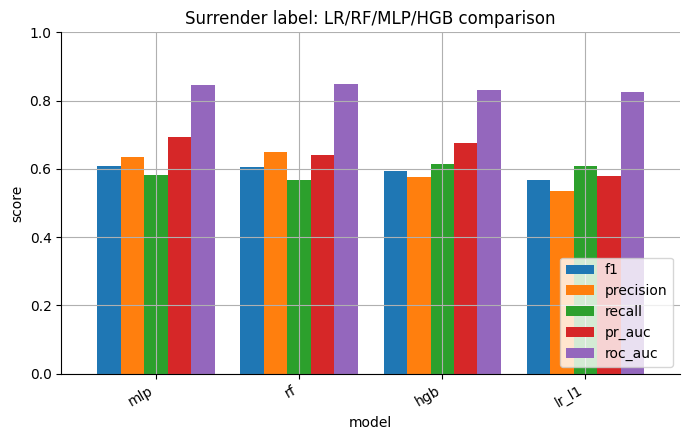

In [2]:
df = load_team_features(RIOT_3)
metrics_surrender = evaluate_models(df, 'team_surrendered', models=('lr_l1', 'rf', 'mlp', 'hgb'), seeds=(42,))
plot_metric_bars(summarize_metrics(metrics_surrender), 'Surrender label: LR/RF/MLP/HGB comparison')

## 2. Final loss label에서 MLP 비교

,model,threshold,accuracy,f1,precision,recall,pr_auc,roc_auc,n_features,positive_rate_test
0,mlp,0.33,0.7327,0.7765,0.6671,0.9287,0.8563,0.8525,12.0,0.5
1,rf,0.36,0.7297,0.7692,0.6711,0.9010,0.8561,0.8474,12.0,0.5
2,lr_l1,0.37,0.7376,0.7640,0.6942,0.8495,0.8296,0.8351,12.0,0.5
3,hgb,0.45,0.7455,0.7618,0.7160,0.8139,0.8664,0.8560,12.0,0.5


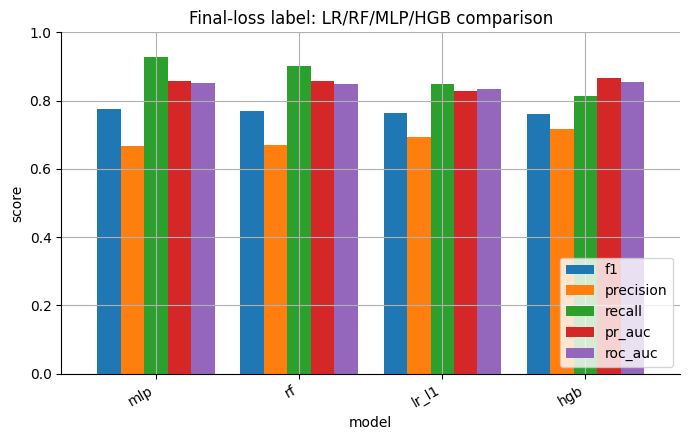

In [3]:
metrics_loss = evaluate_models(df, 'final_loss', models=('lr_l1', 'rf', 'mlp', 'hgb'), seeds=(42,))
plot_metric_bars(summarize_metrics(metrics_loss), 'Final-loss label: LR/RF/MLP/HGB comparison')

## 3. 두 label의 best model confusion matrix

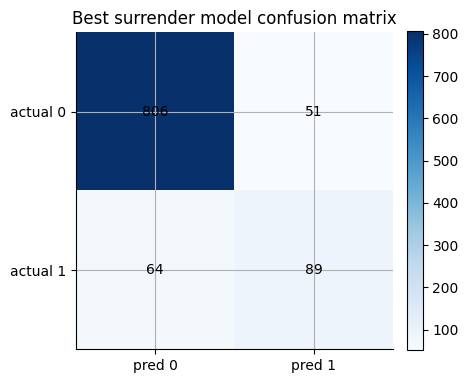

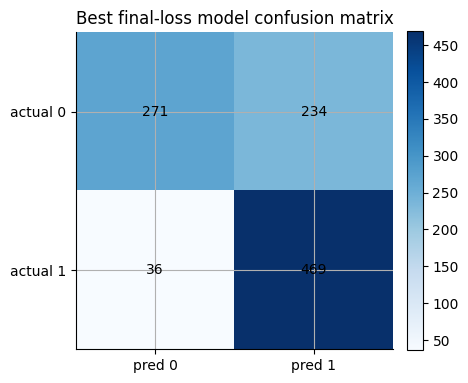

In [4]:
plot_confusion_matrix_from_metrics(metrics_surrender, summarize_metrics(metrics_surrender).index[0], 'Best surrender model confusion matrix')
plot_confusion_matrix_from_metrics(metrics_loss, summarize_metrics(metrics_loss).index[0], 'Best final-loss model confusion matrix')

## 4. 판단
- MLP는 일부 split에서 좋아 보일 수 있지만, 안정성/설명력 면에서 L1 Logistic Regression을 대체할 만큼 명확하지 않다.
- 최종 본문은 black-box보다 설명 가능한 모델과 label contract 개선에 둔다.